In [11]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib
from sklearn.decomposition import PCA

plt.style.use("seaborn-v0_8-talk")
matplotlib.rcParams['font.family'] = 'Arial'

In [12]:
rng = np.random.default_rng(0)

N = 400
G = 2000
B = 4

Kb = 5
Kh = 5
Ks = 5

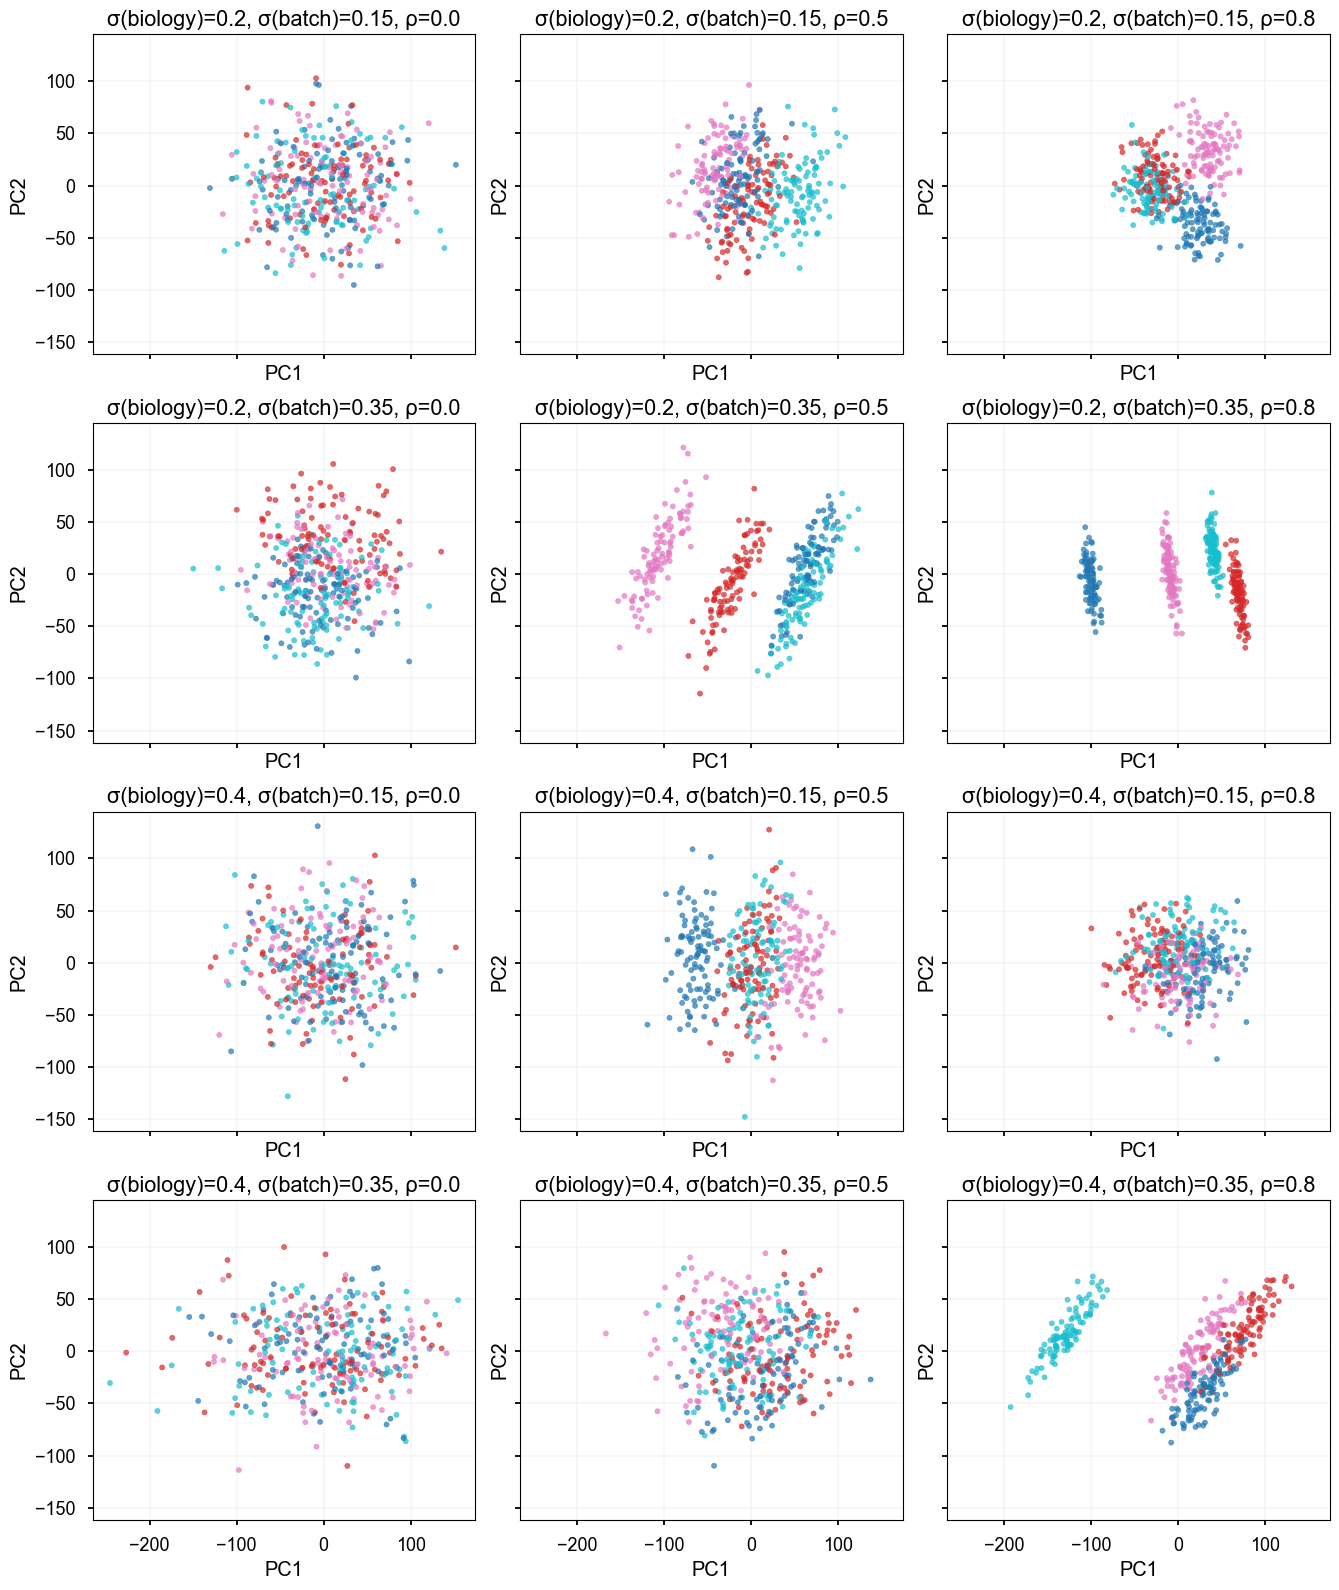

In [15]:
batch_ids = np.repeat(np.arange(B), N // B)
rng.shuffle(batch_ids)

def generate_log_intensity(sigma_l, sigma_p, rho):
    # gene baseline
    mu = rng.normal(0, 1.0, size=G)

    # gene loadings
    L = rng.normal(0, sigma_l, size=(G, Kb))
    P = rng.normal(0, sigma_p, size=(G, Kh))
    Q = rng.normal(0, 0.30,    size=(G, Ks))  # shared loading 고정

    # latents
    Z = rng.normal(0, 1.0, size=(N, Kb))
    H = rng.normal(0, 1.0, size=(B, Kh))

    # shared construction
    Wb = rng.normal(0, 1.0, size=(Kb, Ks))
    Wh = rng.normal(0, 1.0, size=(Kh, Ks))

    Zs = Z @ Wb
    Hs = H @ Wh

    S = np.zeros((N, Ks))
    for i in range(N):
        b = batch_ids[i]
        S[i] = np.sqrt(1 - rho) * Zs[i] + np.sqrt(rho) * Hs[b]

    # log intensity
    M = np.zeros((N, G))
    for i in range(N):
        b = batch_ids[i]
        bio    = Z[i] @ L.T
        batch  = H[b] @ P.T
        shared = S[i] @ Q.T
        eps    = rng.normal(0, sigma_eps, size=G)
        M[i] = mu + bio + batch + shared + eps

    return M

def plot_pca_grid(sigma_l_list, sigma_p_list, rho_list):
    n_rows = len(sigma_l_list) * len(sigma_p_list)
    n_cols = len(rho_list)

    fig, axes = plt.subplots(
        n_rows, n_cols,
        figsize=(4.5 * n_cols, 4 * n_rows),
        sharex=True, sharey=True
    )

    row = 0
    for sigma_l in sigma_l_list:
        for sigma_p in sigma_p_list:
            for col, rho in enumerate(rho_list):
                M = generate_log_intensity(
                    sigma_l=sigma_l,
                    sigma_p=sigma_p,
                    rho=rho
                )

                X = M - M.mean(axis=0, keepdims=True)
                PCs = PCA(n_components=2).fit_transform(X)

                ax = axes[row, col]
                ax.scatter(
                    PCs[:, 0], PCs[:, 1],
                    c=batch_ids,
                    s=14, alpha=0.7,
                    cmap='tab10'
                )

                ax.set_title(
                    f"σ(biology)={sigma_l}, σ(batch)={sigma_p}, ρ={rho}"
                )
                ax.set_xlabel("PC1")
                ax.set_ylabel("PC2")
                ax.grid(alpha=0.1)
            row += 1

    plt.tight_layout()
    plt.show()

sigma_l_list = [0.2, 0.4]        # biology
sigma_p_list = [0.15, 0.35]      # batch
rho_list     = [0.0, 0.5, 0.8]   # shared
sigma_eps    = 0.05              # 고정 (지금은)

plot_pca_grid(
    sigma_l_list=sigma_l_list,
    sigma_p_list=sigma_p_list,
    rho_list=rho_list
)


In [98]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# -----------------------------
# 0) helpers
# -----------------------------
def softmax_rows(logits: np.ndarray) -> np.ndarray:
    x = logits - logits.max(axis=1, keepdims=True)
    ex = np.exp(x)
    return ex / ex.sum(axis=1, keepdims=True)

def sample_log_t_library_sizes(N, mu_L=np.log(2e6), sigma_L=1.0, nu=4, rng=None):
    """Extremely heavy-tailed library sizes via log-Student-t."""
    rng = np.random.default_rng() if rng is None else rng
    t = rng.standard_t(df=nu, size=N)
    logL = mu_L + sigma_L * t
    L = np.exp(logL)
    return L, logL

def nb_sample(mu, alpha, rng):
    """
    NB2: Var = mu + alpha*mu^2 (Gamma-Poisson mixture)
    mu: (N,G), alpha: (G,)
    """
    eps = 1e-12
    alpha = np.maximum(alpha, eps)
    shape = 1.0 / alpha[None, :]
    scale = alpha[None, :] * mu
    lam = rng.gamma(shape=shape, scale=scale)
    return rng.poisson(lam)

# -----------------------------
# 1) 3-latent log-intensity generator
# -----------------------------
def generate_log_intensity_3latent(
    N=400, G=2000, B=8,
    Kb=4, Kh=3, Ks=3,
    sigma_l=0.35, sigma_p=0.25, sigma_q=0.30,
    rho=0.5, sigma_eps=0.05,
    rng=None
):
    rng = np.random.default_rng(0) if rng is None else rng

    # batch assignment
    batch_ids = np.repeat(np.arange(B), N // B)
    rng.shuffle(batch_ids)

    # gene baselines + loadings
    mu = rng.normal(0, 1.0, size=G)
    L = rng.normal(0, sigma_l, size=(G, Kb))  # biology loading
    P = rng.normal(0, sigma_p, size=(G, Kh))  # batch loading
    Q = rng.normal(0, sigma_q, size=(G, Ks))  # shared loading

    # latents
    Z = rng.normal(0, 1.0, size=(N, Kb))      # biology latent (sample)
    H = rng.normal(0, 1.0, size=(B, Kh))      # batch latent (batch)

    # map Z, H -> shared space Ks then mix with rho
    Wb = rng.normal(0, 1.0, size=(Kb, Ks))
    Wh = rng.normal(0, 1.0, size=(Kh, Ks))
    Zs = Z @ Wb
    Hs = H @ Wh

    S = np.zeros((N, Ks))
    for i in range(N):
        b = batch_ids[i]
        S[i] = np.sqrt(1 - rho) * Zs[i] + np.sqrt(rho) * Hs[b]  # shared/confounded

    # log-intensity
    M = np.zeros((N, G))
    for i in range(N):
        b = batch_ids[i]
        bio = Z[i] @ L.T
        bat = H[b] @ P.T
        sh  = S[i] @ Q.T
        eps = rng.normal(0, sigma_eps, size=G)
        M[i] = mu + bio + bat + sh + eps

    comps = {
        "batch_ids": batch_ids,
        "mu_gene": mu,
        "L": L, "P": P, "Q": Q,
        "Z": Z, "H": H, "S": S
    }
    return M, comps

# -----------------------------
# 2) log-intensity -> counts with heavy-tail scale + overdispersion + dropout
# -----------------------------
def counts_from_log_intensity(
    M_log,
    mode="NB",                      # "NB" or "DM"
    # heavy-tailed library size
    mu_L=np.log(2e6), sigma_L=1.0, nu_L=4,
    # NB dispersion prior
    mu_alpha=-2.0, sigma_alpha=1.0,
    # DM concentration prior
    mu_kappa=3.0, sigma_kappa=0.7,
    # dropout
    dropout=True, b_drop=-1.2, a0=-2.0, sigma_a=0.7,
    rng=None
):
    rng = np.random.default_rng(1) if rng is None else rng
    N, G = M_log.shape
    eps = 1e-8

    # composition via softmax
    pi = softmax_rows(M_log)                 # (N,G), sums to 1
    L, logL = sample_log_t_library_sizes(N, mu_L=mu_L, sigma_L=sigma_L, nu=nu_L, rng=rng)
    L_int = np.maximum(1, np.round(L)).astype(int)

    mu_ij = L[:, None] * pi                  # expected mean counts

    if mode.upper() == "NB":
        alpha = rng.lognormal(mean=mu_alpha, sigma=sigma_alpha, size=G)  # gene-wise dispersion
        Y_pre = nb_sample(mu_ij, alpha, rng)

    elif mode.upper() == "DM":
        kappa = rng.lognormal(mean=mu_kappa, sigma=sigma_kappa, size=N)
        Y_pre = np.zeros((N, G), dtype=int)
        for i in range(N):
            theta = kappa[i] * pi[i] + eps
            p = rng.dirichlet(theta)
            Y_pre[i] = rng.multinomial(L_int[i], p)
        alpha = None
    else:
        raise ValueError("mode must be 'NB' or 'DM'")

    if dropout:
        a = rng.normal(loc=a0, scale=sigma_a, size=G)
        drop_prob = 1.0 / (1.0 + np.exp(-(a[None, :] + b_drop * np.log(mu_ij + eps))))
        keep = rng.binomial(1, 1.0 - drop_prob, size=(N, G))
        Y = Y_pre * keep
    else:
        a, drop_prob = None, None
        Y = Y_pre

    return {
        "Y": Y, "Y_pre": Y_pre,
        "pi": pi, "L": L, "logL": logL, "mu": mu_ij,
        "alpha": alpha, "drop_prob": drop_prob, "a_gene": a
    }

# -----------------------------
# 3) quick PCA plotting
# -----------------------------
def plot_pca(mat, batch_ids, title, log1p=False):
    X = np.log1p(mat) if log1p else mat
    X = X - X.mean(axis=0, keepdims=True)
    PCs = PCA(n_components=2).fit_transform(X)
    plt.figure(figsize=(5,4))
    plt.scatter(PCs[:,0], PCs[:,1], c=batch_ids, cmap="tab10", s=16, alpha=0.75)
    plt.title(title)
    plt.xlabel("PC1"); plt.ylabel("PC2")
    plt.tight_layout()
    plt.grid(alpha=0.1)
    plt.show()


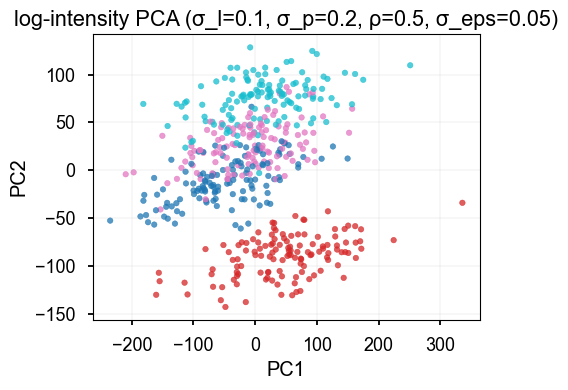

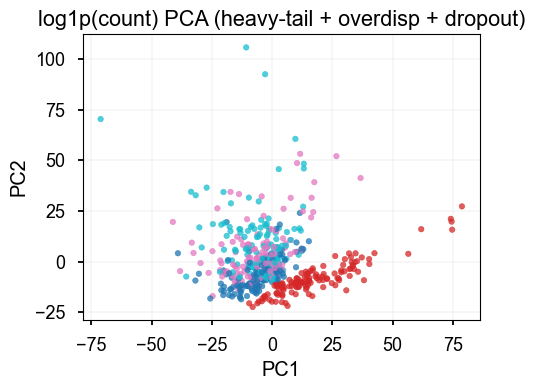

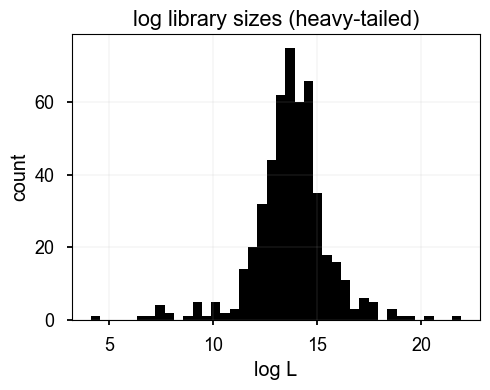

Y shape: (500, 8000)
Mean library size: 12503157.873236824
Median library size: 916944.7408903374
Zero fraction: 0.97216325


In [99]:
# =========================================================
# RUN: pick arbitrary params (dummy) and generate data
# =========================================================
rng = np.random.default_rng(0)
N = 500
G = 8000
B = 4

Kb = 5
Kh = 5
Ks = 5
# ---- user-requested arbitrary params (edit these freely)
sigma_l  = 0.1
sigma_p  = 0.2
rho      = 0.50
sigma_eps= 0.05

M_log, comps = generate_log_intensity_3latent(
    N=N, G=G, B=B,
    Kb=Kb, Kh=Kh, Ks=Ks,
    sigma_l=sigma_l, sigma_p=sigma_p, rho=rho, sigma_eps=sigma_eps,
    rng=rng
)

batch_ids = comps["batch_ids"]

plot_pca(M_log, batch_ids, title=f"log-intensity PCA (σ_l={sigma_l}, σ_p={sigma_p}, ρ={rho}, σ_eps={sigma_eps})")

out = counts_from_log_intensity(
    M_log,
    mode="DM",           # try "DM" too
    mu_L=np.log(1e6), sigma_L=1.1, nu_L=3,   # heavier tail: increase sigma_L or decrease nu_L
    mu_alpha=-3.0, sigma_alpha=1.,
    mu_kappa=3.0, sigma_kappa=0.7,
    dropout=True, b_drop=-1.2, a0=-2.0, sigma_a=0.7,
    rng=rng
)
Y = out["Y"]

# visualize PCA on log1p counts
plot_pca(Y, batch_ids, title="log1p(count) PCA (heavy-tail + overdisp + dropout)", log1p=True)

# (C) quick sanity diagnostics (optional)
plt.figure(figsize=(5,4))
plt.hist(out["logL"], bins=40, color='black')
plt.title("log library sizes (heavy-tailed)")
plt.xlabel("log L"); plt.ylabel("count")
plt.grid(alpha=0.1)
plt.tight_layout()
plt.show()

zero_frac = (Y == 0).mean()
print("Y shape:", Y.shape)
print("Mean library size:", float(out["L"].mean()))
print("Median library size:", float(np.median(out["L"])))
print("Zero fraction:", float(zero_frac))

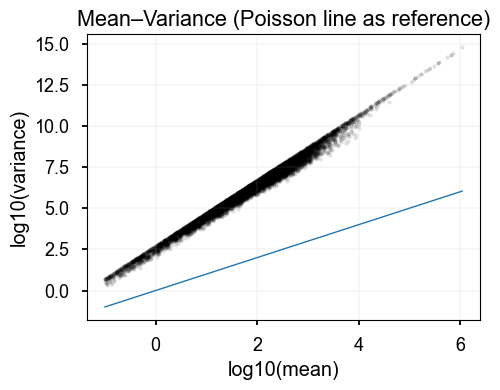

In [100]:
def mean_variance_plot(Y, min_mean=0.1):
    mu = Y.mean(axis=0)
    va = Y.var(axis=0, ddof=1)

    keep = mu >= min_mean
    mu, va = mu[keep], va[keep]

    plt.figure(figsize=(5, 4))
    plt.scatter(np.log10(mu + 1e-8), np.log10(va + 1e-8), s=6, alpha=0.1, color='black')
    # Poisson reference: Var = Mean
    x = np.linspace(np.min(np.log10(mu + 1e-8)), np.max(np.log10(mu + 1e-8)), 200)
    plt.plot(x, x, linewidth=1)  # log10(Var)=log10(Mean)
    plt.xlabel("log10(mean)")
    plt.ylabel("log10(variance)")
    plt.title("Mean–Variance (Poisson line as reference)")
    plt.tight_layout()
    plt.grid(alpha=0.1)
    plt.show()

mean_variance_plot(Y)


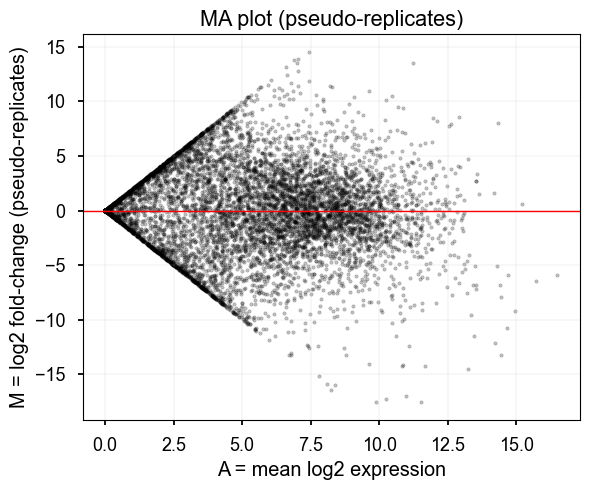

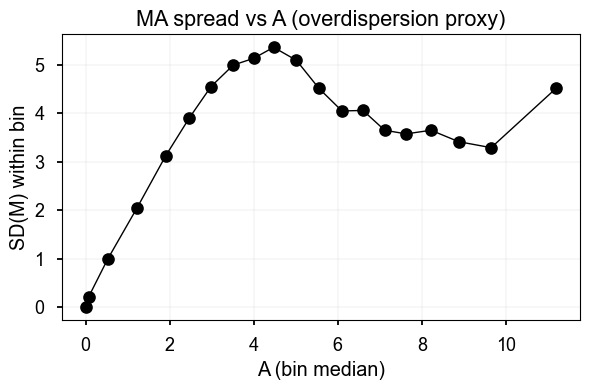

In [101]:
import numpy as np
import matplotlib.pyplot as plt

def ma_plot_pseudorep(Y, batch_ids=None, batch_to_use=None, seed=0, pseudocount=1.0):
    rng = np.random.default_rng(seed)
    N, G = Y.shape

    if batch_ids is not None and batch_to_use is not None:
        idx = np.where(batch_ids == batch_to_use)[0]
    else:
        idx = np.arange(N)

    rng.shuffle(idx)
    half = len(idx) // 2
    g1, g2 = idx[:half], idx[half:2*half]

    # group means (avoid zeros with pseudocount)
    mu1 = Y[g1].mean(axis=0)
    mu2 = Y[g2].mean(axis=0)

    A = 0.5 * (np.log2(mu1 + pseudocount) + np.log2(mu2 + pseudocount))
    M = np.log2(mu1 + pseudocount) - np.log2(mu2 + pseudocount)

    plt.figure(figsize=(6, 5))
    plt.scatter(A, M, s=6, alpha=0.25, color='black')
    plt.axhline(0, linewidth=1, color='red')
    plt.xlabel("A = mean log2 expression")
    plt.ylabel("M = log2 fold-change (pseudo-replicates)")
    title = "MA plot (pseudo-replicates)"
    if batch_to_use is not None:
        title += f" | batch={batch_to_use}"
    plt.title(title)
    plt.grid(alpha=0.1)
    plt.tight_layout()
    plt.show()

    # quantify spread vs A by binning
    bins = np.quantile(A, np.linspace(0, 1, 21))
    bin_id = np.digitize(A, bins[1:-1], right=True)
    spread = np.array([np.std(M[bin_id == k]) for k in range(20)])
    centers = np.array([np.median(A[bin_id == k]) for k in range(20)])

    plt.figure(figsize=(6, 4))
    plt.plot(centers, spread, marker="o", linewidth=1, color='black')
    plt.xlabel("A (bin median)")
    plt.ylabel("SD(M) within bin")
    plt.title("MA spread vs A (overdispersion proxy)")
    plt.grid(alpha=0.1)
    plt.tight_layout()
    plt.show()

# 예시:
# 전체에서
ma_plot_pseudorep(Y, batch_ids=None, batch_to_use=None, seed=0)

# 특정 batch 내부에서 (더 공정하게 technical replicate에 가까움)
# ma_plot_pseudorep(Y, batch_ids=batch_ids, batch_to_use=0, seed=0)


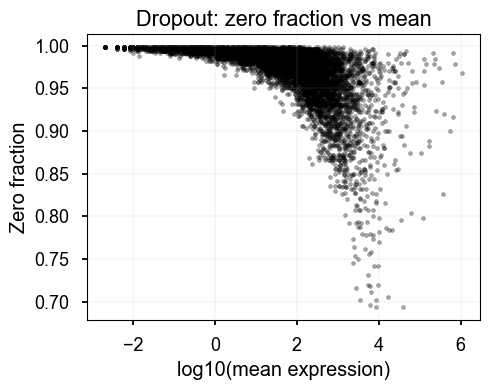

In [106]:
def zero_fraction_vs_mean(Y, min_mean=0.0):
    mu = Y.mean(axis=0)
    zero_frac = (Y == 0).mean(axis=0)

    keep = mu > min_mean
    mu = mu[keep]
    zero_frac = zero_frac[keep]

    plt.figure(figsize=(5,4))
    plt.scatter(
        np.log10(mu + 1e-8),
        zero_frac,
        s=8,
        alpha=0.35,
        color='black'
    )
    plt.xlabel("log10(mean expression)")
    plt.ylabel("Zero fraction")
    plt.title("Dropout: zero fraction vs mean")
    plt.tight_layout()
    plt.grid(alpha=0.1)
    plt.show()

zero_fraction_vs_mean(Y)